# US 14

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Carregar o dataset das declarações
declarations_df = pd.read_csv("../Dados/dataset1_declarations.csv")

# Converter a data para o formato datetime
declarations_df["declaration_date"] = pd.to_datetime(
    declarations_df["declaration_date"], errors="coerce"
)

# Garantir que as colunas numéricas estão no formato correto
numeric_columns = [
    "gross_salary",
    "side_income_consulting",
    "side_income_board_memberships",
    "assets_in_real_estate",
    "assets_in_vehicles",
    "assets_in_stocks",
]

for column in numeric_columns:
    declarations_df[column] = pd.to_numeric(declarations_df[column], errors="coerce")

# Remover linhas sem agente ou sem data, porque são necessárias para escolher a declaração mais recente
analysis_df = declarations_df.dropna(subset=["agent_id", "declaration_date"]).copy()

# Criar variáveis totais pedidas no enunciado
analysis_df["total_income"] = (
    analysis_df["gross_salary"].fillna(0)
    + analysis_df["side_income_consulting"].fillna(0)
    + analysis_df["side_income_board_memberships"].fillna(0)
)

analysis_df["total_assets"] = (
    analysis_df["assets_in_real_estate"].fillna(0)
    + analysis_df["assets_in_vehicles"].fillna(0)
    + analysis_df["assets_in_stocks"].fillna(0)
)

# Para cada agente político, considerar apenas a declaração mais recente
latest_declarations = (
    analysis_df.sort_values(["agent_id", "declaration_date"])
    .drop_duplicates(subset="agent_id", keep="last")
    .copy()
)

print(f"Total de declarações no dataset: {len(declarations_df)}")
print(f"Declarações mais recentes consideradas: {len(latest_declarations)}")
latest_declarations.head()


Total de declarações no dataset: 13395
Declarações mais recentes consideradas: 2364


,agent_id,role,declaration_type,declaration_date,declaration_id,institution,gross_salary,side_income_consulting,side_income_board_memberships,assets_in_real_estate,assets_in_vehicles,assets_in_stocks,total_income,total_assets
2,A00001,MP,regular,2026-01-15,D000002,Parliament,61227.440378,26782.410048,9141.892217,16945.613880,4244.493958,29924.280475,97151.742643,51114.388314
10,A00002,MP,regular,2026-01-15,D000010,Parliament,57375.603650,2160.907291,28786.217969,31307.245383,23585.301270,6891.053695,88322.728910,61783.600348
18,A00003,MP,regular,2026-01-15,D000018,Parliament,59624.595619,51260.243645,9943.989849,414.754603,50615.983385,18889.226093,120828.829113,69919.964081
26,A00004,MP,regular,2026-01-15,D000026,Parliament,50857.316968,9467.933636,19170.525593,2037.358169,13464.043085,16588.249485,79495.776197,32089.650740
31,A00005,MP,regular,2026-01-15,D000031,Parliament,67297.524657,13334.391476,128525.296248,34017.852685,26649.856645,15998.666148,209157.212382,76666.375478


### Medidas descritivas

In [3]:
# Função simples para calcular medidas de localização e variabilidade
def descriptive_measures(series):
    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0] if not series.mode().empty else np.nan,
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "variance": series.var(),
        "std_dev": series.std(),
        "q1": series.quantile(0.25),
        "q3": series.quantile(0.75),
        "iqr": series.quantile(0.75) - series.quantile(0.25),
    })

# Calcular as medidas para rendimento total e património total
summary_stats = pd.DataFrame({
    "total_income": descriptive_measures(latest_declarations["total_income"]),
    "total_assets": descriptive_measures(latest_declarations["total_assets"]),
})

summary_stats.round(2)


,total_income,total_assets
count,2.364000e+03,2.364000e+03
mean,9.988131e+04,5.937253e+04
median,9.573734e+04,5.368864e+04
mode,2.335001e+04,1.772460e+03
min,2.335001e+04,1.772460e+03
max,2.564204e+05,2.438996e+05
range,2.330704e+05,2.421271e+05
variance,1.008252e+09,1.189392e+09
std_dev,3.175298e+04,3.448756e+04
q1,7.799904e+04,3.406546e+04


### Distribuição do rendimento total

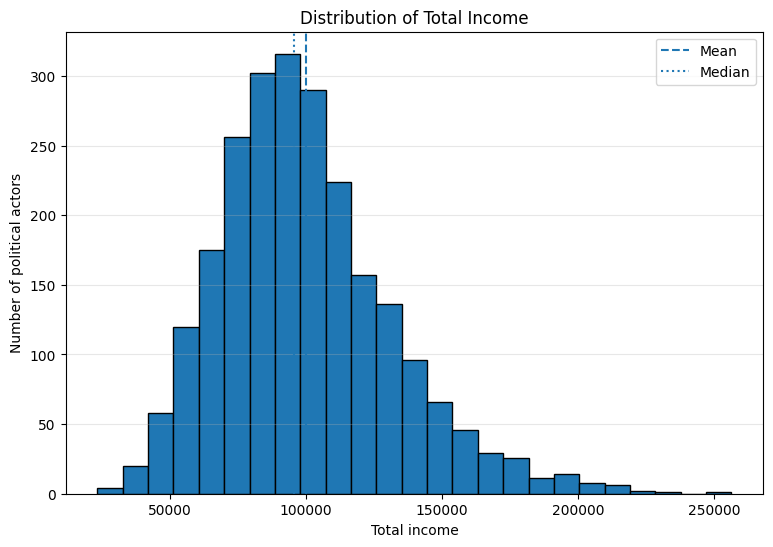

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

# Histograma para observar a forma da distribuição do rendimento total
ax.hist(latest_declarations["total_income"], bins=25, edgecolor="black")
ax.axvline(latest_declarations["total_income"].mean(), linestyle="--", label="Mean")
ax.axvline(latest_declarations["total_income"].median(), linestyle=":", label="Median")

ax.set_title("Distribution of Total Income")
ax.set_xlabel("Total income")
ax.set_ylabel("Number of political actors")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()


### Distribuição do património total

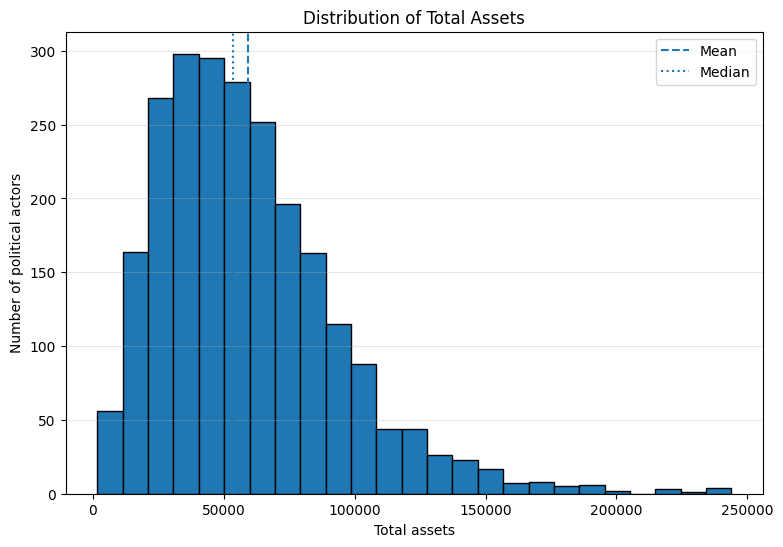

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

# Histograma para observar a forma da distribuição do património total
ax.hist(latest_declarations["total_assets"], bins=25, edgecolor="black")
ax.axvline(latest_declarations["total_assets"].mean(), linestyle="--", label="Mean")
ax.axvline(latest_declarations["total_assets"].median(), linestyle=":", label="Median")

ax.set_title("Distribution of Total Assets")
ax.set_xlabel("Total assets")
ax.set_ylabel("Number of political actors")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.show()


### Comparação visual da variabilidade

/tmp/ipykernel_129410/1388946673.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


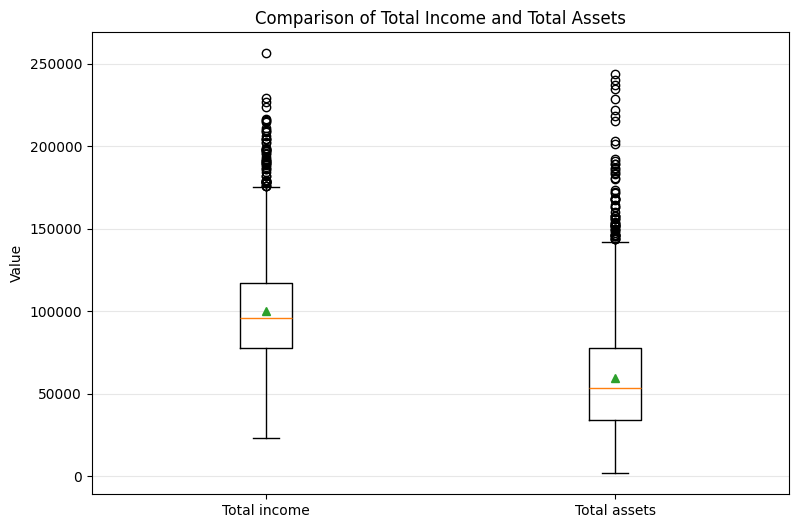

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

# Boxplot para comparar dispersão e possíveis outliers
ax.boxplot(
    [latest_declarations["total_income"], latest_declarations["total_assets"]],
    labels=["Total income", "Total assets"],
    showmeans=True,
)

ax.set_title("Comparison of Total Income and Total Assets")
ax.set_ylabel("Value")
ax.grid(axis="y", alpha=0.3)

plt.show()


### Interpretação simples

In [7]:
income_mean = latest_declarations["total_income"].mean()
income_median = latest_declarations["total_income"].median()
assets_mean = latest_declarations["total_assets"].mean()
assets_median = latest_declarations["total_assets"].median()

print("Simple interpretation:")

if income_mean > income_median:
    print("- Total income is right-skewed: some political actors have much higher income than the majority.")
else:
    print("- Total income is relatively balanced around the centre.")

if assets_mean > assets_median:
    print("- Total assets are right-skewed: some political actors have much higher assets than the majority.")
else:
    print("- Total assets are relatively balanced around the centre.")

print("- The boxplot helps identify dispersion and possible outliers in both variables.")
print("- Only the most recent declaration of each political actor was used, as required in the user story.")


Simple interpretation:
- Total income is right-skewed: some political actors have much higher income than the majority.
- Total assets are right-skewed: some political actors have much higher assets than the majority.
- The boxplot helps identify dispersion and possible outliers in both variables.
- Only the most recent declaration of each political actor was used, as required in the user story.
